In [2]:
import pandas as pd

# 1. Read input CSV files

In [29]:
wind = pd.read_csv(
    "../Yashaswi/dim_wind_clean.csv",
    parse_dates=["Date/Time"]
)

pollutant = pd.read_csv(
    "../Yashaswi/DimPollutants/AQI_PM2.5_2010_2024.csv",
    parse_dates=["Date"]
)

stations = pd.read_csv("../Yashaswi/stations_with_municipality_and_province.csv")

C:\Users\biauser\AppData\Local\Temp\ipykernel_11476\2533365875.py:1: DtypeWarning: Columns (0: Climate ID) have mixed types. Specify dtype option on import or set low_memory=False.
  wind = pd.read_csv(


In [30]:
print(pollutant_csd.columns.tolist())
print(wind_csd.columns.tolist())

['CSDNAME', 'Date', 'Pollutant', 'Concentration']
['CSDNAME', 'Date/Time', 'WindSpeed']


In [31]:
wind = wind.rename(columns={"Date/Time": "Date"})

# 2. Clean column names (optional but safer)

In [32]:
wind.columns = wind.columns.str.strip()
pollutant.columns = pollutant.columns.str.strip()
stations.columns = stations.columns.str.strip()

# 3. Attach CSDNAME to wind data

In [33]:
wind = wind.merge(
    stations[["Station ID", "CSDNAME"]],
    left_on="Climate ID",
    right_on="Station ID",
    how="left"
)


# 4. Attach CSDNAME to pollutant data

In [34]:
pollutant["NAPS ID"] = pollutant["NAPS ID"].astype(str)
stations["Station ID"] = stations["Station ID"].astype(str)

pollutant = pollutant.merge(
    stations[["Station ID", "CSDNAME"]],
    left_on="NAPS ID",
    right_on="Station ID",
    how="left"
)


# 5. Drop missing essentials

In [35]:
wind = wind.dropna(
    subset=["CSDNAME", "Spd of Max Gust (km/h)"]
)

pollutant = pollutant.dropna(
    subset=["CSDNAME", "Pollutant", "C"]
)

# Wind: CSD-level daily mean wind speed

In [36]:
wind_csd = (
    wind
    .groupby(["CSDNAME", "Date"], as_index=False)
    ["Spd of Max Gust (km/h)"]
    .mean()
    .rename(columns={
        "Spd of Max Gust (km/h)": "WindSpeed"
    })
)

# Pollutants: CSD-level daily mean concentration

In [37]:

pollutant_csd = (
    pollutant
    .groupby(["CSDNAME", "Date", "Pollutant"], as_index=False)
    ["C"]
    .mean()
    .rename(columns={"C": "Concentration"})
)

# 7. Join wind and pollutant data

In [38]:


df = pollutant_csd.merge(
    wind_csd,
    on=["CSDNAME", "Date"],
    how="inner"
)

# 8. Correlation calculation

In [40]:
correlation = (
    df
    .groupby(["CSDNAME", "Pollutant"])
    .apply(lambda x: x["Concentration"].corr(x["WindSpeed"]))
    .reset_index(name="Wind_Concentration_Correlation")
)
correlation

,CSDNAME,Pollutant,Wind_Concentration_Correlation
0,Cape Breton,PM2.5,0.056735
1,Fredericton,PM2.5,-0.141632
2,St. John's,PM2.5,-0.084255


In [43]:
df.groupby(["CSDNAME", "Pollutant"]).filter(lambda x: len(x) < 2)

,CSDNAME,Date,Pollutant,Concentration,WindSpeed


In [44]:
wind_dates = set(wind["Date"])
poll_dates = set(pollutant["Date"])

len(wind_dates & poll_dates)

5479

In [45]:

pollutantPM25["CSDNAME"].nunique()
pollutantPM25["CSDNAME"].unique()


<StringArray>
[            'St. John's',            'Mount Pearl',    'Grand Falls-Windsor',
           'Corner Brook',            'Cape Breton',            'Fredericton',
                'Moncton',               'Montréal',             'Mont-Royal',
                  'Laval',               'Gatineau',                 'Québec',
           'Saint-Anicet',           'L'Assomption',                 'Ottawa',
                'Windsor',               'Kingston',                'Toronto',
            'Mississauga',               'Hamilton',                 'London',
               'Winnipeg',                 'Regina',              'Saskatoon',
               'Edmonton',      'Strathcona County',                'Calgary',
               'Red Deer',           'Medicine Hat',             'Lethbridge',
      'Fort Saskatchewan',           'Wood Buffalo',         'Grande Prairie',
                'Burnaby',             'Port Moody',              'Vancouver',
        'North Vancouver',            

In [46]:
pollutant["Pollutant"].value_counts()

Pollutant
PM2.5    270044
Name: count, dtype: int64

In [47]:
wind_csd["CSDNAME"].nunique()
wind_csd["CSDNAME"].unique()

<StringArray>
[             'Allardville',                     'Alma',
                   'Burton',              'Cape Breton',
                 'Carleton', 'Channel-Port aux Basques',
      'Cumberland, Subd. A',      'Cumberland, Subd. B',
                   'Dieppe', 'Division No.  1, Subd. G',
 'Division No.  2, Subd. L', 'Division No.  3, Subd. B',
 'Division No.  7, Subd. A', 'Division No.  8, Subd. A',
 'Division No.  9, Subd. C', 'Division No.  9, Subd. D',
 'Division No. 11, Subd. E',              'Fredericton',
                   'Gander',              'Grand Manan',
              'Guysborough',                  'Halifax',
   'Happy Valley-Goose Bay',                 'Hopedale',
       'Inverness, Subd. A',       'Inverness, Subd. C',
                'Kentville',           'Kings, Subd. A',
                  'Kinkora',                  'Lincoln',
                'Lunenburg',                 'Makkovik',
           'Mary's Harbour',               'Millertown',
                '

In [48]:
pm25_csds = set(pollutantPM25["CSDNAME"].unique())
wind_csds = set(wind_csd["CSDNAME"].unique())

pm25_csds & wind_csds

{'Cape Breton', 'Fredericton', "St. John's"}

In [49]:
target_provinces = ["Nova Scotia", "Newfoundland and Labrador",
                    "Prince Edward Island", "New Brunswick"]

In [50]:
stations["Province"].unique()

<StringArray>
['Newfoundland and Labrador',               'Nova Scotia',
             'New Brunswick',                    'Quebec',
                   'Ontario',                  'Manitoba',
              'Saskatchewan',                   'Alberta',
          'British Columbia',                     'Yukon',
     'Northwest Territories',      'Prince Edward Island']
Length: 12, dtype: str

In [51]:
stations_atlantic = stations[
    stations["Province"].isin(target_provinces)
].copy()

In [52]:
pollutantPM25["NAPS ID"] = pollutantPM25["NAPS ID"].astype(str)
stations_atlantic["Station ID"] = stations_atlantic["Station ID"].astype(str)

pollutant_atlantic = pollutantPM25.merge(
    stations_atlantic[["Station ID", "Province"]],
    left_on="NAPS ID",
    right_on="Station ID",
    how="inner"
)

pollutant_station_counts = (
    pollutant_atlantic
    .groupby("Province")["NAPS ID"]
    .nunique()
)

pollutant_station_counts

Province
New Brunswick                2
Newfoundland and Labrador    4
Nova Scotia                  1
Name: NAPS ID, dtype: int64

In [56]:

print("pollutant_atlantic columns:")
print(pollutant_atlantic.columns.tolist())

print("\nwind_atlantic columns:")
print(wind_atlantic.columns.tolist())

print("\nstations_atlantic columns:")
print(stations_atlantic.columns.tolist())


pollutant_atlantic columns:
['NAPS ID', 'Date', 'Pollutant', 'Year', 'C', 'AQI', 'Station ID_x', 'CSDNAME', 'Station ID_y', 'Province']

wind_atlantic columns:
['Index', 'Climate ID', 'Date', 'Dir of Max Gust (10s deg)', 'Spd of Max Gust (km/h)', 'Station ID_x', 'CSDNAME', 'Station ID_y', 'Province']

stations_atlantic columns:
['Station ID', 'Latitude', 'Longitude', 'CSDUID', 'CSDNAME', 'Province']


In [57]:
aqi_station_names = (
    pollutant_atlantic
    [["Province", "NAPS ID", "CSDNAME"]]
    .drop_duplicates()
    .sort_values(["Province", "CSDNAME"])
)

aqi_station_names

,Province,NAPS ID,CSDNAME
1291,New Brunswick,40103,Fredericton
1650,New Brunswick,40302,Moncton
884,Newfoundland and Labrador,10602,Corner Brook
723,Newfoundland and Labrador,10501,Grand Falls-Windsor
358,Newfoundland and Labrador,10401,Mount Pearl
0,Newfoundland and Labrador,10102,St. John's
1241,Nova Scotia,30310,Cape Breton


In [53]:
wind["Climate ID"] = wind["Climate ID"].astype(str)

wind_atlantic = wind.merge(
    stations_atlantic[["Station ID", "Province"]],
    left_on="Climate ID",
    right_on="Station ID",
    how="inner"
)

wind_station_counts = (
    wind_atlantic
    .groupby("Province")["Climate ID"]
    .nunique()
)

wind_station_counts

Province
New Brunswick                16
Newfoundland and Labrador    26
Nova Scotia                  27
Prince Edward Island          5
Name: Climate ID, dtype: int64

In [58]:
wind_station_names = (
    wind_atlantic
    [["Province", "Climate ID", "CSDNAME"]]
    .drop_duplicates()
    .sort_values(["Province", "CSDNAME"])
)

wind_station_names

,Province,Climate ID,CSDNAME
186296,New Brunswick,8104295,Allardville
11453,New Brunswick,8101746,Alma
12618,New Brunswick,8101792,Burton
93606,New Brunswick,8102326,Carleton
135196,New Brunswick,8103202,Dieppe
...,...,...,...
106573,Prince Edward Island,8305500,Kinkora
64513,Prince Edward Island,830P001,North Shore
254499,Prince Edward Island,8300590,North Shore
246207,Prince Edward Island,8300562,St. Peters


In [54]:
pollutant_station_ids = set(pollutant_atlantic["NAPS ID"].unique())
wind_station_ids = set(wind_atlantic["Climate ID"].unique())

common_station_ids = pollutant_station_ids & wind_station_ids

len(common_station_ids), common_station_ids

(0, set())

# 9. Sort and display results

In [42]:
correlation = correlation.sort_values(
    ["CSDNAME", "Pollutant"]
)
correlation

,CSDNAME,Pollutant,Wind_Concentration_Correlation
0,Cape Breton,PM2.5,0.056735
1,Fredericton,PM2.5,-0.141632
2,St. John's,PM2.5,-0.084255


#  Prepare province‑level PM2.5 data

In [59]:
pm25_prov_daily = (
    pollutant_atlantic
    .groupby(["Province", "Date"], as_index=False)
    ["C"]
    .mean()
    .rename(columns={"C": "PM25"})
)

# Prepare province‑level wind data

In [61]:
wind_prov_daily = (
    wind_atlantic
    .groupby(["Province", "Date"], as_index=False)
    ["Spd of Max Gust (km/h)"]
    .mean()
    .rename(columns={"Spd of Max Gust (km/h)": "WindSpeed"})
)

# Join and compute correlation

In [62]:
prov_daily = pm25_prov_daily.merge(
    wind_prov_daily,
    on=["Province", "Date"],
    how="inner"
)

# Correlation by province

In [63]:
prov_correlation = (
    prov_daily
    .groupby("Province")
    .apply(lambda x: x["PM25"].corr(x["WindSpeed"]))
    .reset_index(name="Wind_PM25_Correlation")
)

prov_correlation

,Province,Wind_PM25_Correlation
0,New Brunswick,-0.150529
1,Newfoundland and Labrador,-0.051987
2,Nova Scotia,-0.002179


## Monthly aggregation (more stable)

In [64]:
prov_daily["Month"] = prov_daily["Date"].dt.to_period("M")

prov_monthly = (
    prov_daily
    .groupby(["Province", "Month"], as_index=False)
    .agg({
        "PM25": "mean",
        "WindSpeed": "mean"
    })
)

## Monthly correlation

In [65]:
prov_monthly_corr = (
    prov_monthly
    .groupby("Province")
    .apply(lambda x: x["PM25"].corr(x["WindSpeed"]))
    .reset_index(name="Monthly_Wind_PM25_Correlation")
)

prov_monthly_corr

,Province,Monthly_Wind_PM25_Correlation
0,New Brunswick,-0.040079
1,Newfoundland and Labrador,0.071065
2,Nova Scotia,0.219182


## Calculate seasonal correlation by province

In [85]:
prov_daily["Season"] = prov_daily["Date"].dt.month.map(
    lambda m: (
        "Winter" if m in [12, 1, 2] else
        "Spring" if m in [3, 4, 5] else
        "Summer" if m in [6, 7, 8] else
        "Fall"
    )
)
seasonal_corr = (
    prov_daily
    .groupby(["Province", "Season"])
    .apply(lambda x: x["PM25"].corr(x["WindSpeed"]))
    .reset_index(name="Wind_PM25_Correlation")
)

seasonal_corr

,Province,Season,Wind_PM25_Correlation
0,New Brunswick,Fall,-0.186873
1,New Brunswick,Spring,-0.078380
2,New Brunswick,Summer,-0.032107
3,New Brunswick,Winter,-0.247377
4,Newfoundland and Labrador,Fall,-0.057632
5,Newfoundland and Labrador,Spring,-0.059952
6,Newfoundland and Labrador,Summer,-0.042075
7,Newfoundland and Labrador,Winter,-0.039960
8,Nova Scotia,Fall,-0.027431
9,Nova Scotia,Spring,0.033705


In [86]:
seasonal_corr_filtered = (
    prov_daily
    .groupby(["Province", "Season"])
    .filter(lambda x: len(x) >= 30)   # at least 30 days
    .groupby(["Province", "Season"])
    .apply(lambda x: x["PM25"].corr(x["WindSpeed"]))
    .reset_index(name="Wind_PM25_Correlation")
)

seasonal_corr_filtered

,Province,Season,Wind_PM25_Correlation
0,New Brunswick,Fall,-0.186873
1,New Brunswick,Spring,-0.078380
2,New Brunswick,Summer,-0.032107
3,New Brunswick,Winter,-0.247377
4,Newfoundland and Labrador,Fall,-0.057632
5,Newfoundland and Labrador,Spring,-0.059952
6,Newfoundland and Labrador,Summer,-0.042075
7,Newfoundland and Labrador,Winter,-0.039960
8,Nova Scotia,Fall,-0.027431
9,Nova Scotia,Spring,0.033705


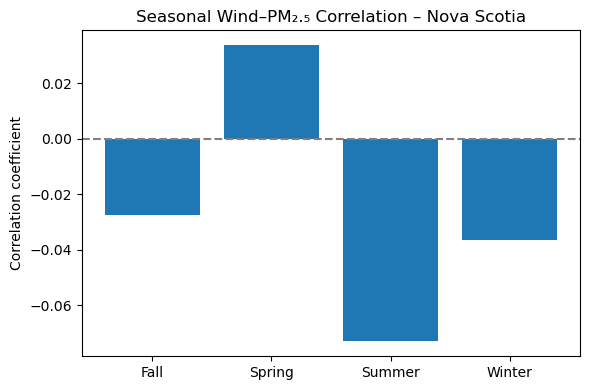

In [91]:
import matplotlib.pyplot as plt

province = "Nova Scotia"
subset = seasonal_corr[
    seasonal_corr["Province"] == province
]

plt.figure(figsize=(6, 4))
plt.bar(subset["Season"], subset["Wind_PM25_Correlation"])
plt.axhline(0, color="gray", linestyle="--")

plt.ylabel("Correlation coefficient")
plt.title(f"Seasonal Wind–PM₂.₅ Correlation – {province}")
plt.tight_layout()
plt.show()

## Scatter plot: Wind speed vs PM₂.₅ (by province)

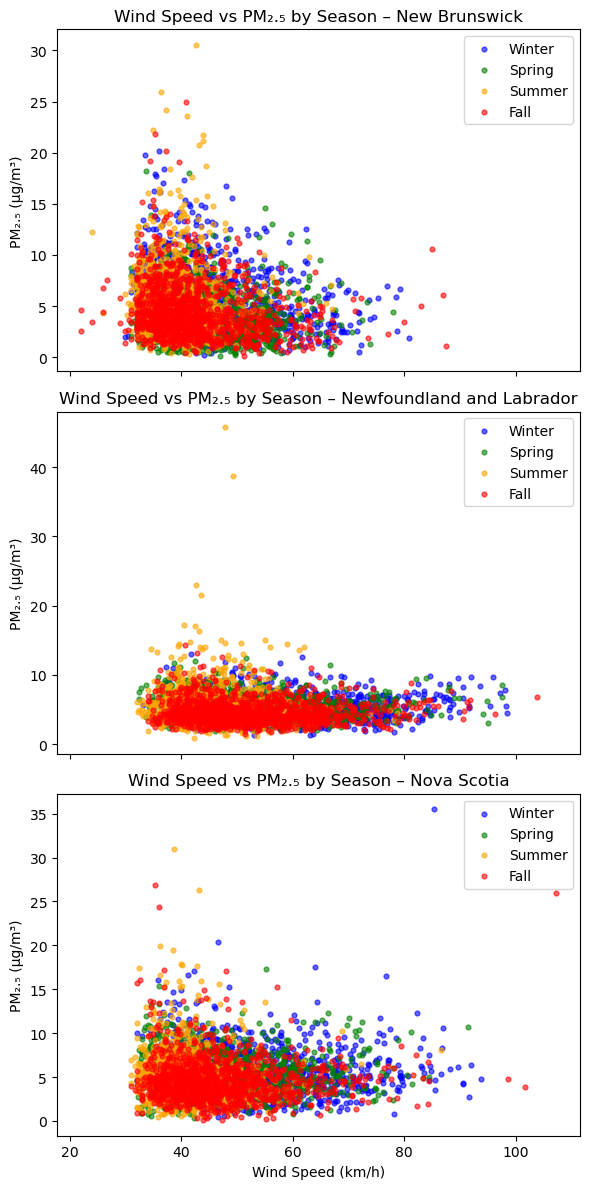

In [82]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Province-level daily aggregation ---
pm25_prov = (
    pollutant_atlantic
    .groupby(["Province", "Date"], as_index=False)["C"]
    .mean()
    .rename(columns={"C": "PM25"})
)

wind_prov = (
    wind_atlantic
    .groupby(["Province", "Date"], as_index=False)["Spd of Max Gust (km/h)"]
    .mean()
    .rename(columns={"Spd of Max Gust (km/h)": "WindSpeed"})
)

prov_daily = pm25_prov.merge(
    wind_prov,
    on=["Province", "Date"],
    how="inner"
)

# --- Add Canadian meteorological seasons ---
prov_daily["Season"] = prov_daily["Date"].dt.month.map(
    lambda m: (
        "Winter" if m in [12, 1, 2] else
        "Spring" if m in [3, 4, 5] else
        "Summer" if m in [6, 7, 8] else
        "Fall"
    )
)

# --- Colors for seasons ---
season_colors = {
    "Winter": "blue",
    "Spring": "green",
    "Summer": "orange",
    "Fall": "red"
}

# --- Scatter plots (one per province) ---
provinces = prov_daily["Province"].unique()

fig, axes = plt.subplots(
    len(provinces), 1,
    figsize=(6, 4 * len(provinces)),
    sharex=True
)

if len(provinces) == 1:
    axes = [axes]

for ax, prov in zip(axes, provinces):
    data = prov_daily[prov_daily["Province"] == prov]

    for season, color in season_colors.items():
        subset = data[data["Season"] == season]
        ax.scatter(
            subset["WindSpeed"],
            subset["PM25"],
            label=season,
            color=color,
            alpha=0.6,
            s=12
        )

    ax.set_title(f"Wind Speed vs PM₂.₅ by Season – {prov}")
    ax.set_ylabel("PM₂.₅ (µg/m³)")
    ax.legend()

axes[-1].set_xlabel("Wind Speed (km/h)")
plt.tight_layout()
plt.show()

## 3D Scatter plot

In [92]:
season_map = {
    "Winter": 0,
    "Spring": 1,
    "Summer": 2,
    "Fall": 3
}

prov_daily["SeasonNum"] = prov_daily["Season"].map(season_map)

C:\Users\biauser\AppData\Local\Temp\ipykernel_11476\1360091030.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


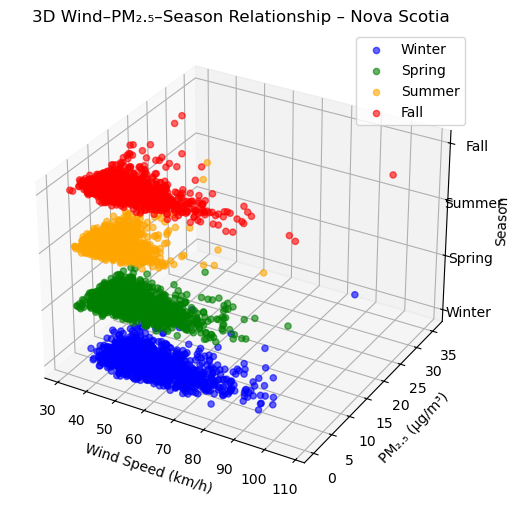

In [95]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

province = "Nova Scotia"
data = prov_daily[prov_daily["Province"] == province]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

for season, color in season_colors.items():
    subset = data[data["Season"] == season]
    ax.scatter(
        subset["WindSpeed"],
        subset["PM25"],
        subset["SeasonNum"],
        color=color,
        alpha=0.6,
        s=20,
        label=season
    )

ax.set_xlabel("Wind Speed (km/h)")
ax.set_ylabel("PM₂.₅ (µg/m³)")
ax.set_zlabel("Season")

ax.set_zticks(list(season_map.values()))
ax.set_zticklabels(list(season_map.keys()))

ax.set_title(f"3D Wind–PM₂.₅–Season Relationship – {province}")
ax.legend()

plt.tight_layout()
plt.show()

## Time‑series overlay (great for intuition)

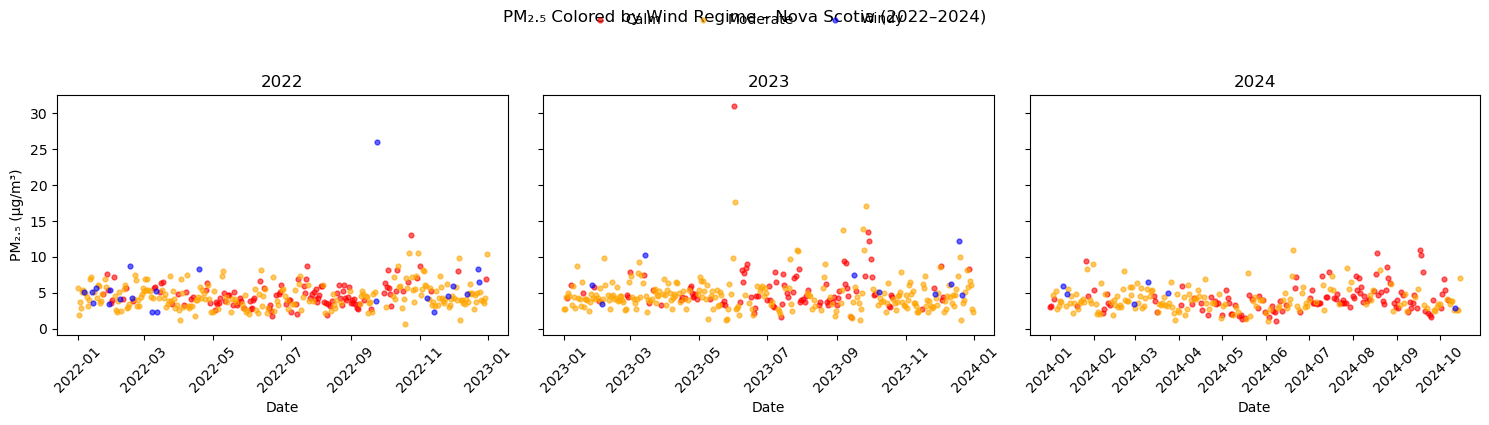

In [80]:

prov_daily["Wind_Regime"] = pd.cut(
    prov_daily["WindSpeed"],
    bins=[0, 40, 70, 200],
    labels=["Calm", "Moderate", "Windy"]
)
import matplotlib.pyplot as plt

province = "Nova Scotia"
years = [2022, 2023, 2024]

subset = prov_daily[
    (prov_daily["Province"] == province) &
    (prov_daily["Date"].dt.year.isin(years))
].copy()

colors = {
    "Calm": "red",
    "Moderate": "orange",
    "Windy": "blue"
}

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 4),
    sharey=True
)

for ax, year in zip(axes, years):
    year_data = subset[subset["Date"].dt.year == year]

    for regime, color in colors.items():
        reg_data = year_data[year_data["Wind_Regime"] == regime]
        ax.scatter(
            reg_data["Date"],
            reg_data["PM25"],
            color=color,
            s=12,
            alpha=0.6,
            label=regime
        )

    ax.set_title(str(year))
    ax.set_xlabel("Date")
    ax.tick_params(axis="x", rotation=45)

# Y‑axis only on leftmost plot
axes[0].set_ylabel("PM₂.₅ (µg/m³)")

# Shared legend (only once)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=3,
    frameon=False
)

fig.suptitle(
    f"PM₂.₅ Colored by Wind Regime – {province} (2022–2024)",
    y=1.05
)

plt.tight_layout()
plt.show()

## Seasonal (winter vs Summer)

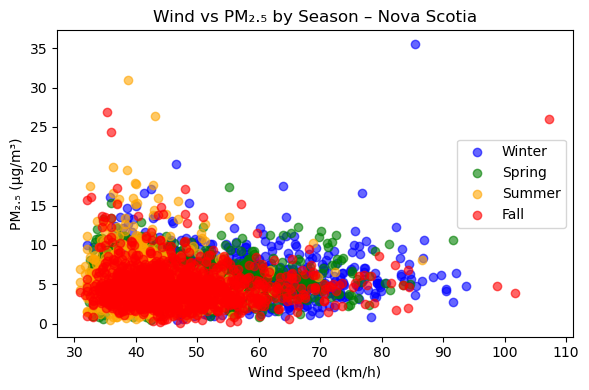

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# --- Add Season column (Canadian meteorological seasons) ---
prov_daily["Season"] = prov_daily["Date"].dt.month.map(
    lambda m: (
        "Winter" if m in [12, 1, 2] else
        "Spring" if m in [3, 4, 5] else
        "Summer" if m in [6, 7, 8] else
        "Fall"
    )
)

province = "Nova Scotia"  # change as needed
data = prov_daily[prov_daily["Province"] == province]

# --- Colors for seasons ---
season_colors = {
    "Winter": "blue",
    "Spring": "green",
    "Summer": "orange",
    "Fall": "red"
}

# --- Plot ---
plt.figure(figsize=(6, 4))

for season, color in season_colors.items():
    subset = data[data["Season"] == season]
    plt.scatter(
        subset["WindSpeed"],
        subset["PM25"],
        label=season,
        color=color,
        alpha=0.6
    )

plt.xlabel("Wind Speed (km/h)")
plt.ylabel("PM₂.₅ (µg/m³)")
plt.title(f"Wind vs PM₂.₅ by Season – {province}")
plt.legend()
plt.tight_layout()
plt.show()

## Color by PM₂.₅ concentration level (high vs low pollution)

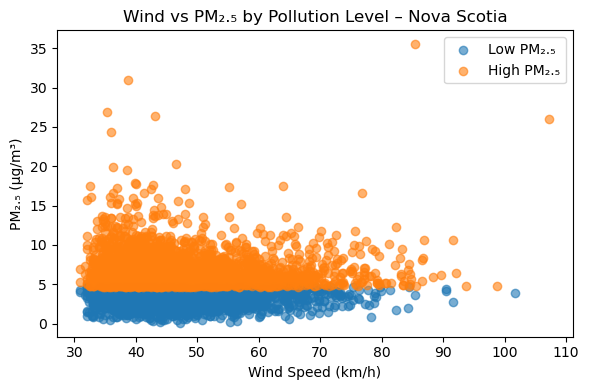

In [71]:
# Create High / Low PM2.5 categories
pm25_threshold = prov_daily["PM25"].median()

prov_daily["PM25_Level"] = np.where(
    prov_daily["PM25"] >= pm25_threshold,
    "High PM₂.₅",
    "Low PM₂.₅"
)

province = "Nova Scotia"
data = prov_daily[prov_daily["Province"] == province]

plt.figure(figsize=(6, 4))

for level, color in [("Low PM₂.₅", "green"), ("High PM₂.₅", "red")]:
    subset = data[data["PM25_Level"] == level]
    plt.scatter(
        subset["WindSpeed"],
        subset["PM25"],
        label=level,
        alpha=0.6
    )

plt.xlabel("Wind Speed (km/h)")
plt.ylabel("PM₂.₅ (µg/m³)")
plt.title(f"Wind vs PM₂.₅ by Pollution Level – {province}")
plt.legend()
plt.tight_layout()
plt.show()

#  Compare PM₂.₅ under wind regimes
- look at calm vs windy regimes
- “Is PM₂.₅ systematically higher on calm days than windy days?”

In [72]:
prov_daily["Wind_Regime"] = pd.cut(
    prov_daily["WindSpeed"],
    bins=[0, 30, 60, 200],
    labels=["Calm", "Moderate", "Windy"]
)

prov_daily.groupby(["Province", "Wind_Regime"])["PM25"].mean()

Province                   Wind_Regime
New Brunswick              Calm           4.805771
                           Moderate       4.949767
                           Windy          3.986950
Newfoundland and Labrador  Moderate       5.148604
                           Windy          4.951057
Nova Scotia                Moderate       5.082685
                           Windy          5.400636
Name: PM25, dtype: float64

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Define wind regimes (adjust thresholds if desired) ---
prov_daily["Wind_Regime"] = pd.cut(
    prov_daily["WindSpeed"],
    bins=[0, 40, 70, 200],
    labels=["Calm", "Moderate", "Windy"]
)

# --- Summary statistics by province and wind regime ---
wind_regime_stats = (
    prov_daily
    .groupby(["Province", "Wind_Regime"])["PM25"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

print(wind_regime_stats)

                    Province Wind_Regime      mean    median  count
0              New Brunswick        Calm  5.286260  4.666667   2319
1              New Brunswick    Moderate  4.585124  4.020833   2547
2              New Brunswick       Windy  4.139120  4.125000     32
3  Newfoundland and Labrador        Calm  5.367519  4.958333    577
4  Newfoundland and Labrador    Moderate  5.063952  4.760417   4168
5  Newfoundland and Labrador       Windy  5.202143  5.131629    364
6                Nova Scotia        Calm  5.380952  4.791667   1374
7                Nova Scotia    Moderate  4.962520  4.583333   3302
8                Nova Scotia       Windy  5.979102  5.166667    166


# NOVA SCOTIA

<Figure size 600x400 with 0 Axes>

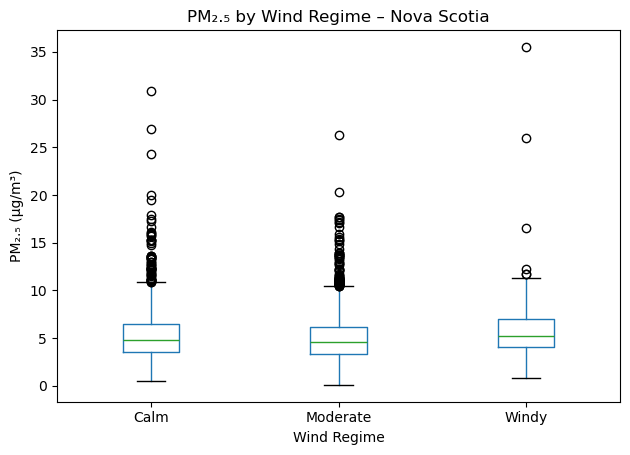

In [74]:
province = "Nova Scotia"  # change as needed
subset = prov_daily[prov_daily["Province"] == province]

plt.figure(figsize=(6, 4))
subset.boxplot(column="PM25", by="Wind_Regime", grid=False)

plt.title(f"PM₂.₅ by Wind Regime – {province}")
plt.suptitle("")  # remove default boxplot title
plt.xlabel("Wind Regime")
plt.ylabel("PM₂.₅ (µg/m³)")
plt.tight_layout()
plt.show()

# Newfoundland and Labrador

<Figure size 600x400 with 0 Axes>

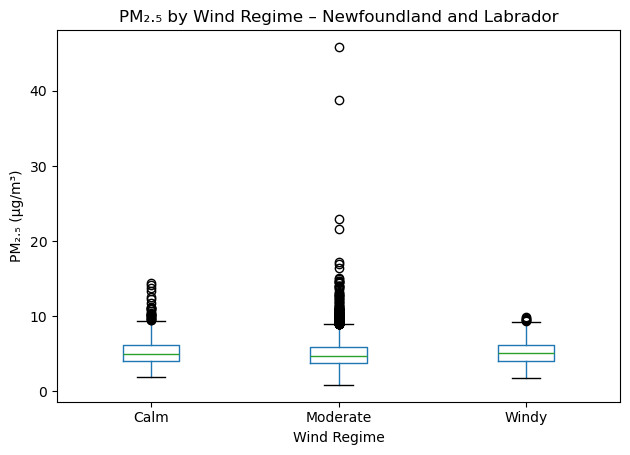

In [76]:
province = "Newfoundland and Labrador"  # change as needed
subset = prov_daily[prov_daily["Province"] == province]

plt.figure(figsize=(6, 4))
subset.boxplot(column="PM25", by="Wind_Regime", grid=False)

plt.title(f"PM₂.₅ by Wind Regime – {province}")
plt.suptitle("")  # remove default boxplot title
plt.xlabel("Wind Regime")
plt.ylabel("PM₂.₅ (µg/m³)")
plt.tight_layout()
plt.show()

# New Brunswick

<Figure size 600x400 with 0 Axes>

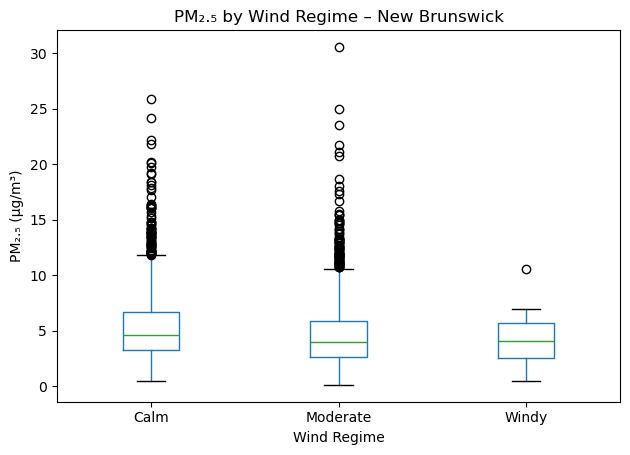

In [77]:
province = "New Brunswick"  # change as needed
subset = prov_daily[prov_daily["Province"] == province]

plt.figure(figsize=(6, 4))
subset.boxplot(column="PM25", by="Wind_Regime", grid=False)

plt.title(f"PM₂.₅ by Wind Regime – {province}")
plt.suptitle("")  # remove default boxplot title
plt.xlabel("Wind Regime")
plt.ylabel("PM₂.₅ (µg/m³)")
plt.tight_layout()
plt.show()